### **Persistence and Streaming**


In [1]:
import os, openai
from dotenv import load_dotenv, find_dotenv
from langchain_openai import ChatOpenAI
from langchain_community.tools.tavily_search import TavilySearchResults
from pprint import pprint

_ = load_dotenv(find_dotenv())
openai.api_key = os.environ['OPENAI_API_KEY']

chat = ChatOpenAI(model = 'gpt-4o', temperature = 0)
tool = TavilySearchResults(max_results = 2)

In [ ]:
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, ToolMessage
from langgraph.graph import MessagesState, StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from typing import Literal

memory = MemorySaver()

class Agent:
    def __init__ (self, chat, tools, checkpointer, system = ''):
        self.system = system

        graph = StateGraph(MessagesState)
        graph.add_node('Large Language Model', self.call_openai)
        graph.add_node('Action', self.take_action)

        graph.set_entry_point('Large Language Model')
        graph.add_conditional_edges('Large Language Model', self.thought)
        graph.add_edge('Action', 'Large Language Model')
        self.graph = graph.compile(checkpointer = checkpointer)

        self.tools = {t.name: t for t in tools}
        self.chat = chat.bind_tools(tools)

    def thought (self, state: MessagesState) -> Literal['Action', END]:
        response = state['messages'][-1]
        return 'Action' if len(response.tool_calls) > 0 else END
    
    def call_openai(self, state: MessagesState):
        messages = state['messages']
        if self.system:
            messages = [SystemMessage(content = self.system)] + messages
        message = self.chat.invoke(messages)
        return {'messages': [message]}
    
    def take_action(self, state: MessagesState):
        tool_calls = state['messages'][-1].tool_calls
        response = []

        for t in tool_calls:
            print (f'Calling: {t}')
            if not t['name'] in self.tools:      # check for bad tool name from LLM
                print("\n ....bad tool name....")
                result = "bad tool name, retry"  # instruct LLM to retry if bad
            else:
                result = self.tools[t['name']].invoke(t['args'])
            response.append(ToolMessage(tool_call_id = t['id'], name = t['name'], content = str(result)))
            
        print('Back to the model!')
        return {'messages': response}

In [3]:
prompt = '''You are a smart research assistant. Use the search engine to look up information. \
You are allowed to make multiple calls (either together or in sequence). \
Only look up information when you are sure of what you want. \
If you need to look up some information before asking a follow up question, you are allowed to do that!
'''

AIbot = Agent(chat, [tool], system = prompt, checkpointer = memory)

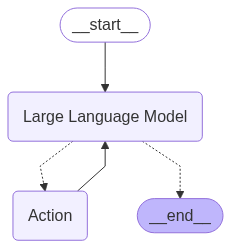

In [4]:
from IPython.display import display, Image

display(Image(AIbot.graph.get_graph().draw_mermaid_png()))

In [11]:
messages = [HumanMessage(content = 'What is the weather in San Francisco?')]
thread = {'configurable': {'thread_id': '1'}}

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_7ZFzEpFUyKxic7juDhpIARnn', 'function': {'arguments': '{"query":"current weather in San Francisco"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1640, 'total_tokens': 1662, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1536}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BcjWxSruTpaW8sGQudNmVAGPADEXA', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0fe0403c-a21b-41ac-ac2e-1cd2cd893e42-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in San Francisco'}, 'id': 'call_7ZFzEpFUyKxic7juDhpIARnn', 'type': 'tool_call'}], usage_

In [ ]:
messages = [HumanMessage(content = 'What about in Los Angeles')]

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_EvVRygCpG4PaDC3r2jBvoV2u', 'function': {'arguments': '{"query":"current weather in Los Angeles"}', 'name': 'tavily_search_results_json'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 22, 'prompt_tokens': 1264, 'total_tokens': 1286, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BcjTwqFuGmGXnPpy7sY3quP4hyg4l', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--12ed4d42-1904-4772-8236-8f987b4c289c-0', tool_calls=[{'name': 'tavily_search_results_json', 'args': {'query': 'current weather in Los Angeles'}, 'id': 'call_EvVRygCpG4PaDC3r2jBvoV2u', 'type': 'tool_call'}], usage_metadat

In [12]:
messages = [HumanMessage(content = 'Which one is warmer?')]

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content='Los Angeles is currently warmer than San Francisco. The daytime temperature in Los Angeles is around 86°F, while in San Francisco, it is about 70°F.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 34, 'prompt_tokens': 2443, 'total_tokens': 2477, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 2304}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BcjXB64Aq5AQlKa5mzIc1pjaZGStJ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--0ca80449-553a-4524-817f-1d0ebc8cac50-0', usage_metadata={'input_tokens': 2443, 'output_tokens': 34, 'total_tokens': 2477, 'input_token_details': {'audio': 0, 'cache_read': 2304}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}


In [13]:
messages = [HumanMessage(content = 'Which one is warmer?')]
thread = {'configurable': {'thread_id': '2'}}

for event in AIbot.graph.stream({'messages': messages}, thread):
    for v in event.values():
        print(v)

{'messages': [AIMessage(content="It seems like you're asking about the temperature comparison between two places, but you've only mentioned Los Angeles. Could you please specify the other location you want to compare with Los Angeles?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 221, 'total_tokens': 257, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_07871e2ad8', 'id': 'chatcmpl-BcjXHFzP2wp6I564c1YPjGwmIstu5', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--092018b3-29e7-4623-9b4c-b82309bf6dbb-0', usage_metadata={'input_tokens': 221, 'output_tokens': 36, 'total_tokens': 257, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'rea